In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score

In [2]:
crop = pd.read_csv("../dataset/crop_feature_engineered.csv")

crop.head()

,nitrogen,phosphorus,potassium,temperature,humidity,soil_ph,rainfall,crop,soil_fertility_score,temp_norm,humidity_norm,rainfall_norm,weather_score,nitrogen_norm,phosphorus_norm,potassium_norm,crop_health_index
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,0.365714,0.345886,0.790267,0.656458,0.597537,0.642857,0.264286,0.190,0.481626
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,0.388571,0.371445,0.770633,0.741675,0.627917,0.607143,0.378571,0.180,0.508244
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,0.326905,0.406854,0.793977,0.875710,0.692180,0.428571,0.357143,0.195,0.509543
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,0.305952,0.506901,0.768751,0.799905,0.691853,0.528571,0.214286,0.175,0.498903
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,0.335476,0.324378,0.785626,0.871231,0.660411,0.557143,0.264286,0.185,0.497944


In [3]:
X = crop.drop("crop", axis=1)

encoder = LabelEncoder()

y = encoder.fit_transform(crop["crop"])

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [5]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.9931818181818182


In [6]:
xgb = XGBClassifier(
    n_estimators=200,
    random_state=42,
    eval_metric="mlogloss"
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_acc)

XGBoost Accuracy: 0.9886363636363636


In [7]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [rf_acc, xgb_acc]
})

comparison

,Model,Accuracy
0,Random Forest,0.993182
1,XGBoost,0.988636


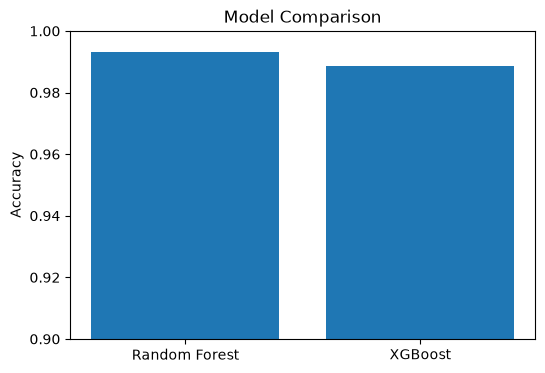

In [8]:
plt.figure(figsize=(6,4))

plt.bar(comparison["Model"], comparison["Accuracy"])

plt.title("Model Comparison")

plt.ylabel("Accuracy")

plt.ylim(0.9,1.0)

plt.show()

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Load feature-engineered dataset
df = pd.read_csv("dataset/crop_feature_engineered.csv")

# Separate input and target
X = df.drop(columns=["label"])
y = df["label"]

# Same 80/20 split used for the model
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

# Prediction probabilities
y_score = rf.predict_proba(X_test)

# Convert labels to binary format
y_test_bin = label_binarize(
    y_test,
    classes=rf.classes_
)

# Plot ROC curve
plt.figure(figsize=(10, 7))

for i in range(len(rf.classes_)):
    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"Class {rf.classes_[i]} (AUC = {roc_auc:.2f})"
    )

# Random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Crop Recommendation")
plt.legend(fontsize=7)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'dataset/crop_feature_engineered.csv'